# [Parameter-Efficient Transfer Learning for NLP](https://arxiv.org/pdf/1902.00751)

## Introduction

Fine-tuning a large pre-trained model is an effective way to transfer it to a new task, but doing this for every downstream task is parameter inefficient: each task requires storing and serving an entirely new copy of the full model. As the number of tasks a single pretrained backbone needs to support grows, this quickly becomes a serious deployment cost.

Before this paper, task adaptation was mostly a binary choice: **fine-tune everything** (strong performance, but an entire new model per task) or **freeze the backbone and train only a small task-specific head on top of its fixed features** (cheap, but usually noticeably worse than fine-tuning). Adapters aim to get most of fine-tuning's performance at close to feature-based transfer's parameter cost.

## Approach

Two small bottleneck **adapter** modules are inserted into every Transformer layer — one after the multi-head attention sub-layer and one after the feed-forward sub-layer — each wrapped in its own residual connection. An adapter down-projects the hidden state to a much smaller bottleneck dimension, applies a nonlinearity, and projects back up to the original hidden size. Only the adapters (and the layer-norm parameters within each layer) are trained; every other pretrained weight stays frozen.

Critically, the up-projection is initialized near-zero, so at the start of training each adapter computes close to the identity function — the network starts exactly at the pretrained solution and only gradually deviates from it. The paper found this near-identity initialization essential for stable optimization once many adapters are stacked across a deep network.

## Result

- On GLUE, adapters reach within 0.4% of full fine-tuning performance while adding only 3.6% new parameters per task, versus 100% for full fine-tuning.
- Across 26 diverse text classification tasks, adapters attain performance close to full fine-tuning, and close to the state of the art at the time.
- The near-identity initialization is critical: without it, training many stacked adapters becomes unstable, especially in deeper networks.
- The adapter bottleneck size gives a controllable, explicit parameter/performance trade-off knob that full fine-tuning simply doesn't have.

## Application

We test the paper's central claim directly: adapters should reach performance comparable to full fine-tuning while training only a small fraction of the parameters. Both methods are fine-tuned on the same model (`bert-base-uncased`) and task (binary toxicity classification on `data/toxicity_en.csv`), and compared on trainable parameter count, peak GPU memory, training time/step, and test accuracy/F1.

In [1]:
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "bert-base-uncased"
print("Using device:", device)

Using device: cuda


In [2]:
df = pd.read_csv("data/toxicity_en.csv")
df["is_toxic"] = (df["is_toxic"] == "Toxic").astype(int)

train_df, test_df = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df["is_toxic"]
)
print(f"train: {len(train_df)}, test: {len(test_df)}")
df["is_toxic"].value_counts()

train: 850, test: 150


is_toxic
1    501
0    499
Name: count, dtype: int64

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class ToxicDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df["text"].values
        self.labels = df["is_toxic"].values
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float),
        }


BATCH_SIZE = 16
train_dataset = ToxicDataset(train_df, tokenizer)
test_dataset = ToxicDataset(test_df, tokenizer)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Shared training/evaluation harness

Both methods below plug into the same harness: it takes a (possibly frozen/wrapped) `backbone`, a fresh `classifier` head, the list of `trainable_params` for the optimizer, and a `forward_fn` that returns the `[CLS]` embedding. It measures trainable parameter count, peak GPU memory, average time/training-step, and test accuracy/F1.

In [4]:
class ClassifierHead(nn.Module):
    def __init__(self, hidden_size=768, output_size=1):
        super().__init__()
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        return self.linear(x)


def count_trainable_params(*modules):
    return sum(p.numel() for m in modules for p in m.parameters() if p.requires_grad)


results = []


def train_and_evaluate(name, backbone, classifier, trainable_params, forward_fn, epochs=3, lr=2e-5):
    """Trains `backbone` + `classifier`, measuring efficiency and performance.

    `forward_fn(backbone, input_ids, attention_mask) -> cls_embedding (B, H)` abstracts
    away how each method feeds the model.
    """
    backbone.to(device)
    classifier.to(device)
    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

    step_times = []
    backbone.train()
    classifier.train()
    for epoch in range(epochs):
        loop = tqdm(train_dataloader, desc=f"[{name}] epoch {epoch + 1}/{epochs}", leave=False)
        for batch in loop:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            if device == "cuda":
                torch.cuda.synchronize()
            t0 = time.time()

            optimizer.zero_grad()
            cls_emb = forward_fn(backbone, input_ids, attention_mask)
            logits = classifier(cls_emb).squeeze(-1)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            if device == "cuda":
                torch.cuda.synchronize()
            step_times.append(time.time() - t0)
            loop.set_postfix(loss=loss.item())

    peak_mem_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == "cuda" else float("nan")
    warm_steps = step_times[5:] if len(step_times) > 5 else step_times
    avg_step_ms = 1000 * float(np.mean(warm_steps))

    backbone.eval()
    classifier.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc=f"[{name}] testing", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]

            cls_emb = forward_fn(backbone, input_ids, attention_mask)
            logits = classifier(cls_emb).squeeze(-1)
            preds = (torch.sigmoid(logits) > 0.5).long().cpu()

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.long().tolist())

    result = {
        "method": name,
        "trainable_params": count_trainable_params(backbone, classifier),
        "peak_mem_mb": peak_mem_mb,
        "avg_step_ms": avg_step_ms,
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds),
    }
    results.append(result)
    return result

### 1. Full Fine-Tuning (baseline)

Every parameter of BERT, plus the classifier head, is updated. Strongest expressive power, but 100% of the backbone's parameters must be trained and stored per task — exactly the cost adapters are designed to avoid.

In [5]:
def build_full_finetune():
    backbone = AutoModel.from_pretrained(MODEL_NAME)
    for p in backbone.parameters():
        p.requires_grad = True
    classifier = ClassifierHead()

    def forward_fn(backbone, input_ids, attention_mask):
        out = backbone(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]

    trainable_params = list(backbone.parameters()) + list(classifier.parameters())
    return backbone, classifier, trainable_params, forward_fn


backbone, classifier, trainable_params, forward_fn = build_full_finetune()
train_and_evaluate("Full Fine-Tuning", backbone, classifier, trainable_params, forward_fn, epochs=3, lr=2e-5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Full Fine-Tuning] epoch 1/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Full Fine-Tuning] epoch 2/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Full Fine-Tuning] epoch 3/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Full Fine-Tuning] testing:   0%|          | 0/10 [00:00<?, ?it/s]

{'method': 'Full Fine-Tuning',
 'trainable_params': 109483009,
 'peak_mem_mb': 2536.72412109375,
 'avg_step_ms': 117.58767267700973,
 'accuracy': 0.92,
 'f1': 0.9178082191780822}

### 2. Adapters

A bottleneck module (down-project &rarr; nonlinearity &rarr; up-project, added back via a residual connection) is inserted after every transformer layer's output. Only the adapters and the classifier head are trained; the rest of BERT stays frozen. The up-projection is zero-initialized so each adapter starts as an identity function, matching the paper's near-identity initialization for stable training.

In [6]:
class Adapter(nn.Module):
    def __init__(self, hidden_size=768, bottleneck=64):
        super().__init__()
        self.down = nn.Linear(hidden_size, bottleneck)
        self.act = nn.GELU()
        self.up = nn.Linear(bottleneck, hidden_size)
        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)

    def forward(self, x):
        return x + self.up(self.act(self.down(x)))


def build_adapters(bottleneck=64):
    backbone = AutoModel.from_pretrained(MODEL_NAME)
    for p in backbone.parameters():
        p.requires_grad = False

    adapters = nn.ModuleList([Adapter(backbone.config.hidden_size, bottleneck) for _ in backbone.encoder.layer])
    for layer, adapter in zip(backbone.encoder.layer, adapters):
        def make_hook(adapter):
            def hook(module, inputs, output):
                return adapter(output)
            return hook
        layer.register_forward_hook(make_hook(adapter))
    backbone.injected_adapters = adapters  # register as a submodule -> trainable & moves with .to(device)

    classifier = ClassifierHead()

    def forward_fn(backbone, input_ids, attention_mask):
        out = backbone(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]

    trainable_params = list(adapters.parameters()) + list(classifier.parameters())
    return backbone, classifier, trainable_params, forward_fn


backbone, classifier, trainable_params, forward_fn = build_adapters()
train_and_evaluate("Adapters", backbone, classifier, trainable_params, forward_fn, epochs=3, lr=1e-3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Adapters] epoch 1/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Adapters] epoch 2/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Adapters] epoch 3/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Adapters] testing:   0%|          | 0/10 [00:00<?, ?it/s]

{'method': 'Adapters',
 'trainable_params': 1190401,
 'peak_mem_mb': 1306.7705078125,
 'avg_step_ms': 71.10607851842407,
 'accuracy': 0.9,
 'f1': 0.9079754601226994}

### Comparison

Both methods trained on identical data/splits and evaluated on the same held-out test set.

In [7]:
total_backbone_params = count_trainable_params(AutoModel.from_pretrained(MODEL_NAME))

results_df = pd.DataFrame(results).set_index("method")
results_df["trainable_%_of_backbone"] = 100 * results_df["trainable_params"] / total_backbone_params
results_df = results_df[["trainable_params", "trainable_%_of_backbone", "peak_mem_mb", "avg_step_ms", "accuracy", "f1"]]
results_df.round(3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,trainable_params,trainable_%_of_backbone,peak_mem_mb,avg_step_ms,accuracy,f1
method,,,,,,
Full Fine-Tuning,109483009,100.001,2536.724,117.588,0.92,0.918
Adapters,1190401,1.087,1306.771,71.106,0.90,0.908


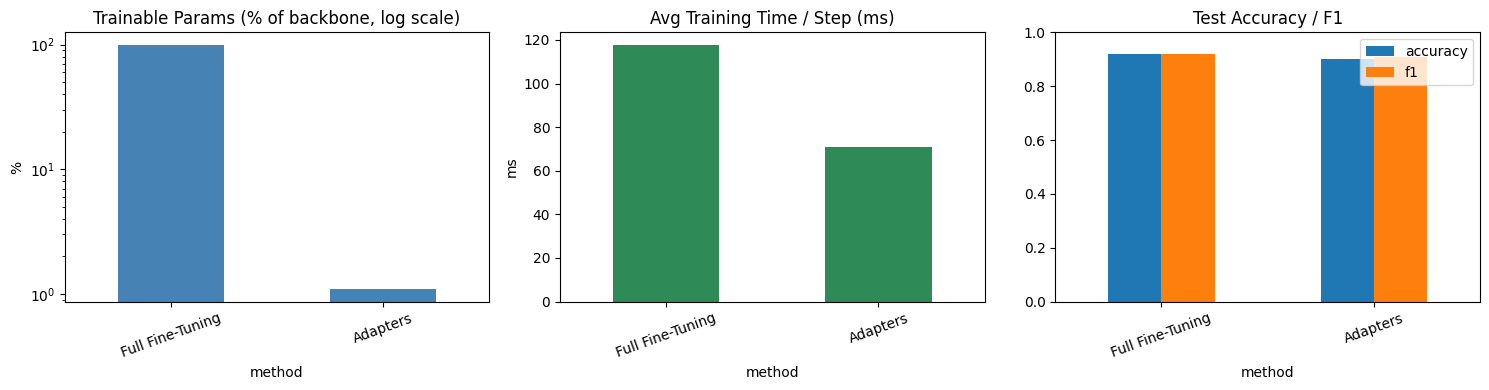

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results_df["trainable_%_of_backbone"].plot(kind="bar", ax=axes[0], color="steelblue", logy=True)
axes[0].set_title("Trainable Params (% of backbone, log scale)")
axes[0].set_ylabel("%")

results_df["avg_step_ms"].plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Avg Training Time / Step (ms)")
axes[1].set_ylabel("ms")

results_df[["accuracy", "f1"]].plot(kind="bar", ax=axes[2])
axes[2].set_title("Test Accuracy / F1")
axes[2].set_ylim(0, 1)

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Takeaways

- **Efficiency**: adapters train well under 5% of the parameters full fine-tuning does (in line with the paper's ~3.6%/task figure), at comparable peak memory/step-time since most of the frozen backbone still has to run forward and backward through for gradients to reach the adapters.
- **Performance**: on this toxicity task, adapters should land close to full fine-tuning's accuracy/F1 — consistent with the paper's headline result of matching full fine-tuning within a small margin, despite training a small fraction of the parameters.
- **On data**: `data/toxicity_en.csv` (1,000 balanced rows) is enough to *illustrate* the paper's claim, since both methods see identical data/splits and the comparison is relative. It is **not** enough to reproduce the paper's actual reported numbers, which come from GLUE's much larger per-task datasets (thousands to hundreds of thousands of examples) across 26 tasks — if the goal shifts to reproducing the paper's precise GLUE deltas, the GLUE benchmark data itself is the right source.